# 052 注意力的逐项计算
从同一实例的手算到两次同步更新，再检查mask与未来泄漏。Run All会重跑全部12配置，不读取保存图片冒充新图。CPU float64、无dropout，完整Notebook需要Noto Sans CJK系统字体；安装与检查见lab.md。新进程内真实IPython核已用于离线验证；浏览器和socket不在该验证范围。

In [1]:
from pathlib import Path
import os,sys,json,io,tempfile,unittest,hashlib,math
root=Path.cwd()
if (root/'units/052').is_dir():root=root/'units/052'
if not (root/'experiment.py').is_file():raise RuntimeError('从课程根或units/052启动Notebook')
sys.path.insert(0,str(root))
import numpy as np,torch
from IPython.display import display,Image
from experiment import attention,reverse,scalar_attention,hand_inputs,objective,hand_ledger,tensor,torch_objective,verify_derivatives,api_probes,leakage_probe,run
import make_figures as figs
import matplotlib.pyplot as plt
import test_experiment
torch.set_num_threads(1)
def require(ok,message):
    if not ok:raise RuntimeError(message)
def show(fig):
    buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=150,bbox_inches='tight');display(Image(data=buffer.getvalue()));plt.close(fig)
print({'torch':torch.__version__,'numpy':np.__version__,'device':'CPU','dtype':'float64','font':figs.FONT})

{'torch': '2.7.1+cpu', 'numpy': '2.3.5', 'device': 'CPU', 'dtype': 'float64', 'font': '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'}


## 1 独立标量前向与shape
这个例子L=3、S=4、dk=2、dv=3，避免只测试方形矩阵和标量value。mask最后一列无效。

Q,K,V,A,O形状: (2, 3, 2) (2, 4, 2) (2, 4, 3) (2, 3, 4) (2, 3, 3)
标量最大差: 2.220446049250313e-16


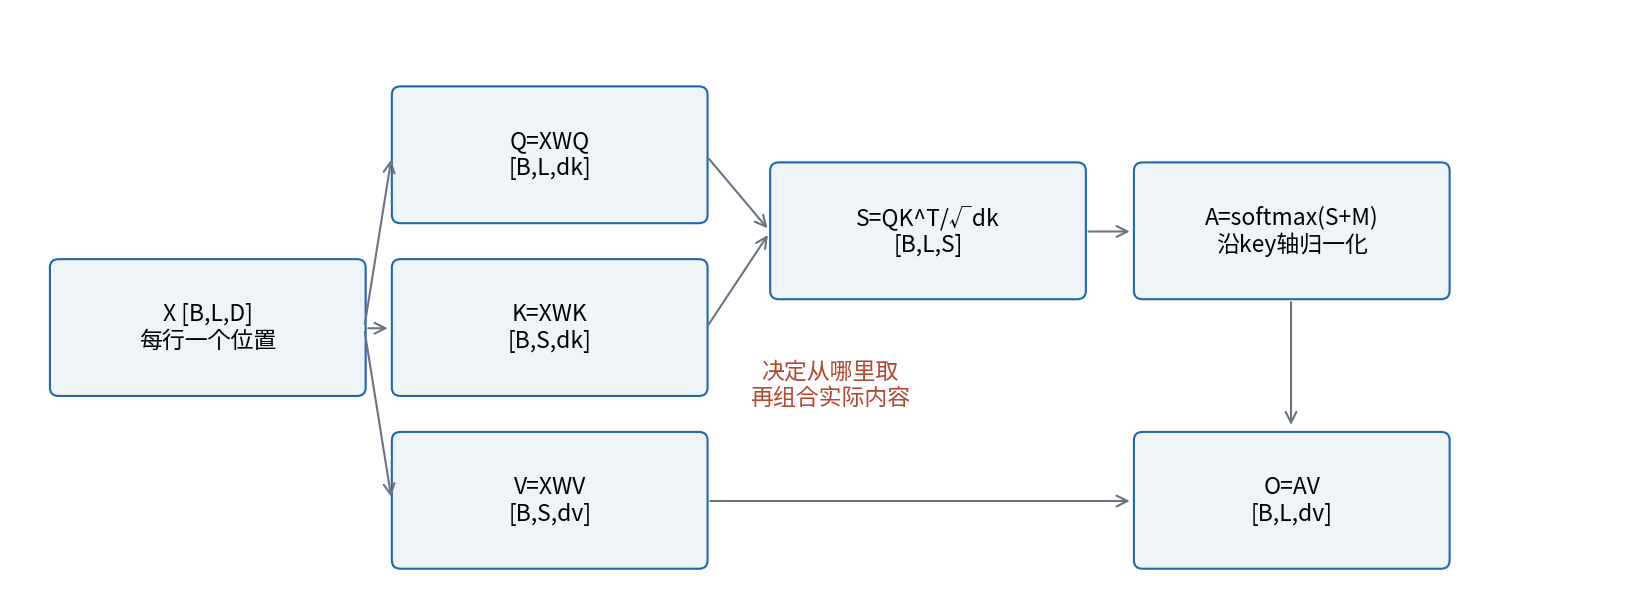

In [2]:
rng=np.random.default_rng(5250)
q=rng.normal(size=(2,3,2)).astype(np.float64);k=rng.normal(size=(2,4,2)).astype(np.float64);v=rng.normal(size=(2,4,3)).astype(np.float64)
allow=np.ones((2,3,4),dtype=np.bool_);allow[:,:,3]=False
o,cache=attention(q,k,v,allow);ref=scalar_attention(q,k,v,allow)
np.testing.assert_allclose(o,ref,atol=3e-15,rtol=1e-14)
print('Q,K,V,A,O形状:',q.shape,k.shape,v.shape,cache['a'].shape,o.shape)
print('标量最大差:',np.max(np.abs(o-ref)))
show(figs.flow({}))

## 2 同一两样本的完整前向
参数共享；不是每个位置单独训练一套W。每个sample loss是该样本两个位置的half-MSE，总loss是两sample loss平均。

state 0 weights [[[0.5], [-0.5]], [[1.0], [0.5]], [[1.0], [-1.0]]] loss 0.016128563004114718
sample 1 Q/K/V [[0.5], [-0.5]] [[1.0], [0.5]] [[1.0], [-1.0]]
score [[0.5, 0.25], [-0.5, -0.25]] A [[0.5621765008857981, 0.4378234991142019], [0.4378234991142019, 0.5621765008857981]] O [[0.1243530017715962], [-0.1243530017715962]]
sample 2 Q/K/V [[0.0], [0.5]] [[1.5], [1.0]] [[0.0], [1.0]]
score [[0.0, 0.0], [0.75, 0.5]] A [[0.5, 0.5], [0.5621765008857981, 0.4378234991142019]] O [[0.5], [0.4378234991142019]]
state 1 weights [[[0.49981268425772], [-0.500773150216442]], [[1.001546300432884], [0.497493233608394]], [[1.0081950270569773], [-0.9960031572116635]]] loss 0.015241267063239023
sample 1 Q/K/V [[0.49981268425772], [-0.500773150216442]] [[1.001546300432884], [0.497493233608394]] [[1.0081950270569773], [-0.9960031572116635]]
score [[0.5005855448277486, 0.24865342848986435], [-0.5015474959553983, -0.24913125380543974]] A [[0.5626520032972752, 0.43734799670272473], [0.4372288691915725, 0.56277

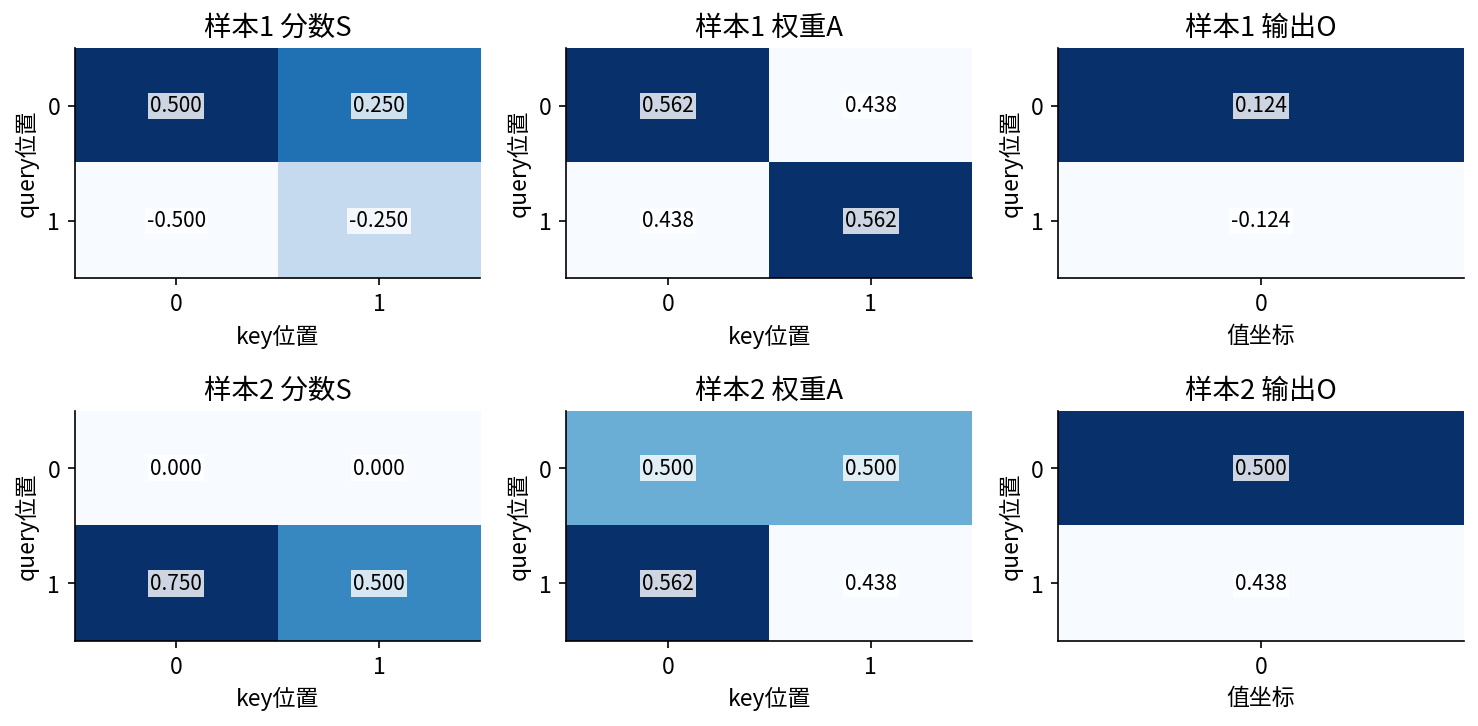

In [3]:
hand=hand_ledger();r={'hand':hand}
for state in hand:
    print('state',state['step'],'weights',state['weights'],'loss',state['loss'])
    for b in range(2):
        print('sample',b+1,'Q/K/V',state['q'][b],state['k'][b],state['v'][b])
        print('score',state['score'][b],'A',state['a'][b],'O',state['prediction'][b])
show(figs.matrices(r))

## 3 完整Jacobian和全部共享路径
所有反向项按旧参数计算。GX包含Q、K、V三条路径；本例X是给定数据，不更新。

state 0 jacobian [[[[ 0.24613408 -0.24613408]
   [-0.24613408  0.24613408]]

  [[ 0.24613408 -0.24613408]
   [-0.24613408  0.24613408]]]


 [[[ 0.25       -0.25      ]
   [-0.25        0.25      ]]

  [[ 0.24613408 -0.24613408]
   [-0.24613408  0.24613408]]]]
state 0 go [[[-0.03141175]
  [ 0.03141175]]

 [[ 0.        ]
  [-0.07804413]]]
state 0 ga [[[-0.03141175  0.03141175]
  [ 0.03141175 -0.03141175]]

 [[ 0.          0.        ]
  [ 0.         -0.07804413]]]
state 0 gs [[[-0.015463    0.015463  ]
  [ 0.015463   -0.015463  ]]

 [[ 0.          0.        ]
  [ 0.01920932 -0.01920932]]]
state 0 gq [[[-0.0077315 ]
  [ 0.0077315 ]]

 [[ 0.        ]
  [ 0.00960466]]]
state 0 gk [[[-0.015463  ]
  [ 0.015463  ]]

 [[ 0.00960466]
  [-0.00960466]]]
state 0 gv [[[-0.00390615]
  [ 0.00390615]]

 [[-0.04387457]
  [-0.03416955]]]
state 0 weight_gradient_per_sample [[[[-7.73150216e-03]
   [ 7.73150216e-03]]

  [[ 9.60465959e-03]
   [ 0.00000000e+00]]]


 [[[-1.54630043e-02]
   [ 1.54630043e-02]]

 

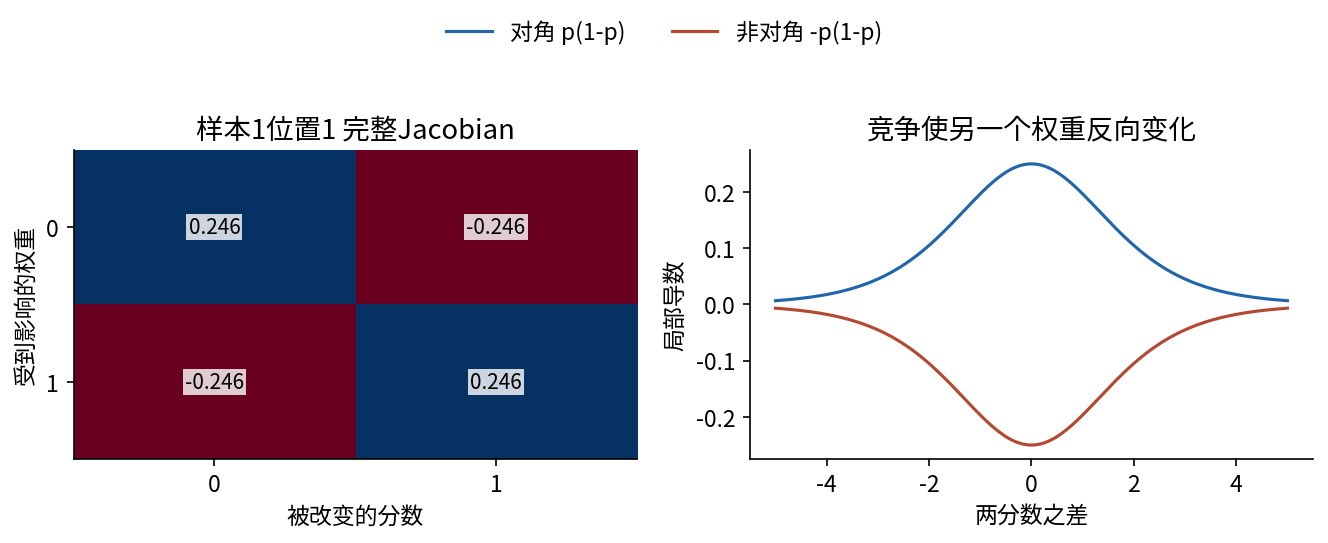

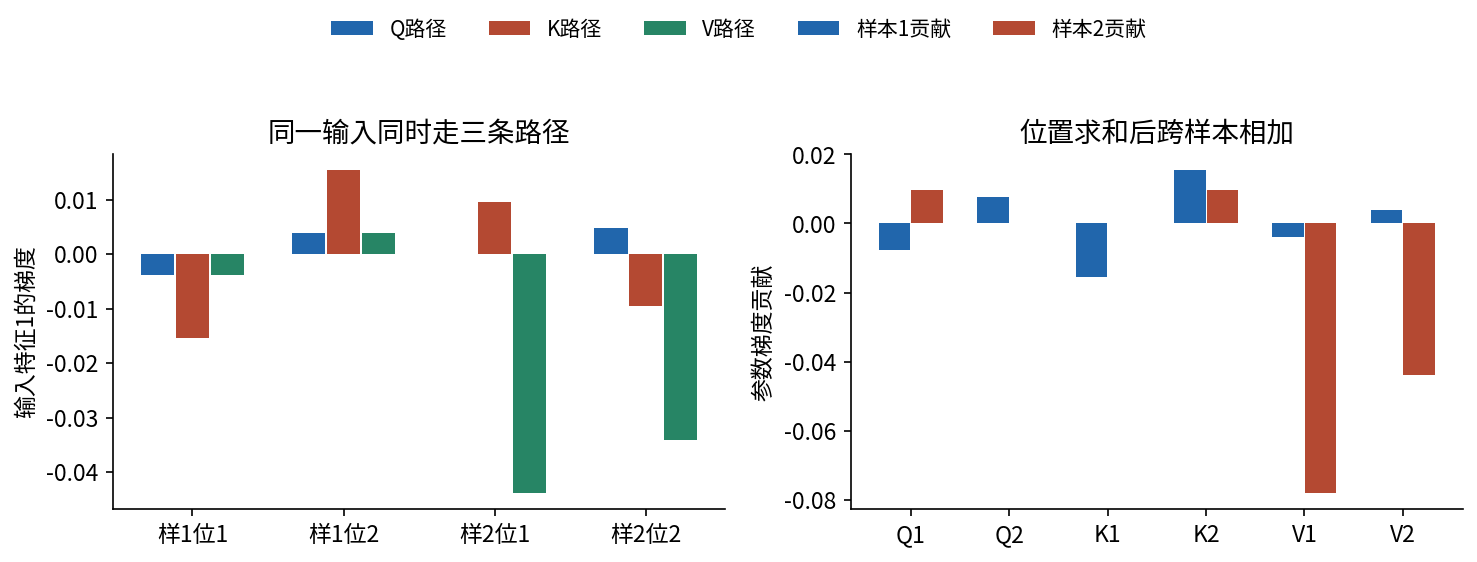

In [4]:
for state in hand:
    for key in ['jacobian','go','ga','gs','gq','gk','gv','weight_gradient_per_sample','weight_gradient','input_gradient_paths','input_gradient']:
        print('state',state['step'],key,np.array(state[key]))
show(figs.jacobian(r))
show(figs.gradient(r))

## 4 两次同步更新与独立有限差分
PyTorch独立重算三轮前向反向；同步更新后的下一轮必须重算全部QKV。

In [5]:
x,y,w=hand_inputs()
for state in hand:
    xt=tensor(x,True);wt=[tensor(z,True) for z in w]
    loss,out=torch_objective(xt,tensor(y),wt);loss.backward()
    np.testing.assert_allclose(out.detach().numpy(),state['prediction'],atol=2e-14)
    for j in range(3):np.testing.assert_allclose(wt[j].grad.numpy(),state['weight_gradient'][j],atol=2e-14)
    print('state',state['step'],'loss',float(loss.detach()),'sample2 position1',float(out[1,0,0].detach()))
    w=[z-.1*t.grad.numpy() for z,t in zip(w,wt)]
deriv=verify_derivatives()
for row in deriv['detail']:print(row)
require(deriv['finite_difference_max_abs']<1e-9,'差分误差过大')
print('最大有限差分误差:',deriv['finite_difference_max_abs'])

state 0 loss 0.016128563004114718 sample2 position1 0.5
state 1 loss 0.01524126706323902 sample2 position1 0.510312427329609
state 2 loss 0.014489698297080595 sample2 position1 0.5197260100902522
{'parameter': 'WQ(0, 0)', 'analytic': 0.0018731574227996636, 'central_difference': 0.001873157422574434, 'abs_error': 2.2522955722692473e-13}
{'parameter': 'WQ(1, 0)', 'analytic': 0.007731502164420202, 'central_difference': 0.007731502164182169, 'abs_error': 2.3803268384137155e-13}
{'parameter': 'WK(0, 0)', 'analytic': -0.015463004328840407, 'central_difference': -0.015463004326629615, 'abs_error': 2.210792313106502e-12}
{'parameter': 'WK(1, 0)', 'analytic': 0.025067663916060277, 'central_difference': 0.02506766391512094, 'abs_error': 9.393354150066813e-13}
{'parameter': 'WV(0, 0)', 'analytic': -0.08195027056977262, 'central_difference': -0.08195027056782933, 'abs_error': 1.9432927489404506e-12}
{'parameter': 'WV(1, 0)', 'analytic': -0.039968427883364445, 'central_difference': -0.0399684278833

## 5 mask契约与库实测
有效query无key会报错。无效query的零行是显式约定，其A和为0。不能用nan_to_num隐藏数学未定义行。

预期拒绝: active query has no allowed key


{
  "torch": "2.7.1+cpu",
  "device": "CPU",
  "dtype": "float64",
  "expected": [
    [
      [
        6.018569295959941,
        3.0185692959599413
      ],
      [
        5.3209538026933725,
        3.6604769013466862
      ]
    ]
  ],
  "closed_form": [
    [
      [
        6.018569295959941,
        3.0185692959599413
      ],
      [
        5.3209538026933725,
        3.6604769013466862
      ]
    ]
  ],
  "sdpa": [
    [
      [
        6.018569295959941,
        3.0185692959599413
      ],
      [
        5.3209538026933725,
        3.6604769013466862
      ]
    ]
  ],
  "mha": [
    [
      [
        6.018569295959941,
        3.0185692959599413
      ],
      [
        5.3209538026933725,
        3.6604769013466862
      ]
    ]
  ],
  "weights": [
    [
      [
        0.33023845067334306,
        0.0,
        0.6697615493266569
      ],
      [
        0.0,
        0.6697615493266569,
        0.33023845067334306
      ]
    ]
  ],
  "sdpa_error": 0.0,
  "mha_error": 

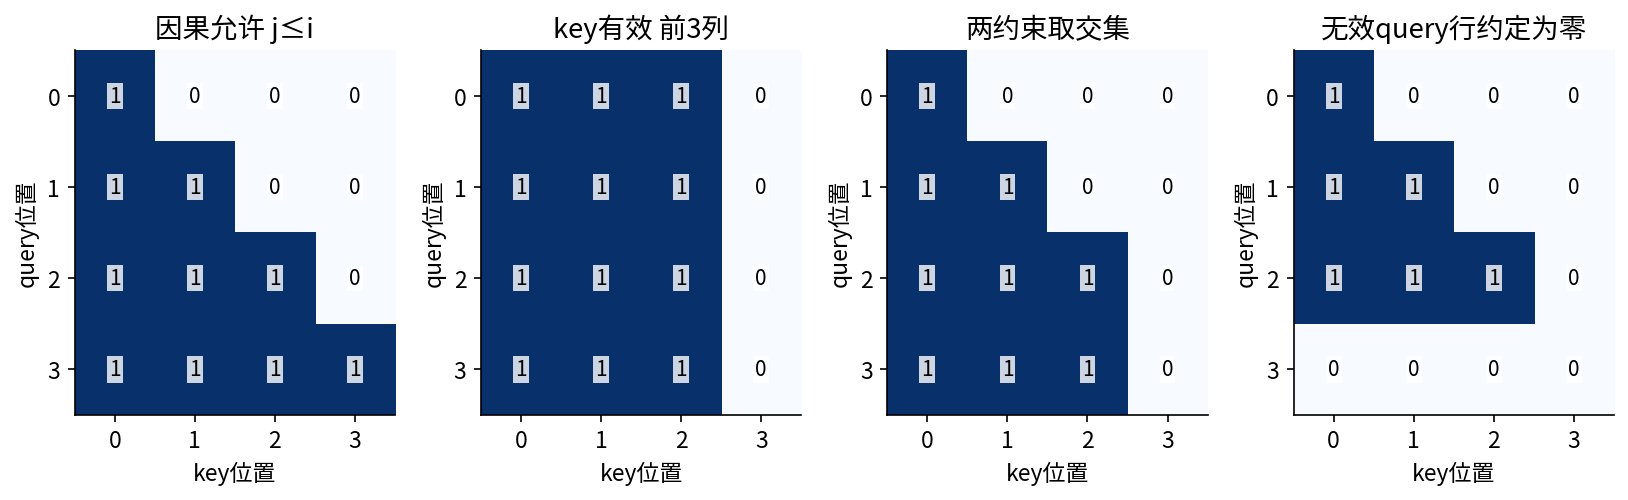

In [6]:
mask=np.ones((2,3,4),dtype=np.bool_);mask[:,2]=False
try:attention(q,k,v,mask)
except ValueError as error:print('预期拒绝:',error)
else:raise RuntimeError('应该拒绝有效query空支持')
valid=np.ones((2,3),dtype=np.bool_);valid[:,2]=False
zero,c=attention(q,k,v,mask,valid);require(np.isfinite(zero).all() and np.all(zero[:,2]==0),'无效query约定错误')
api=api_probes();print(json.dumps(api,ensure_ascii=False,indent=2))
require(api['sdpa_error']<1e-13 and api['mha_error']<1e-13,'API不对齐')
show(figs.masks({}))

## 6 未来信息注入
只更改位置2和3，合法前两个输出应不变。失败是泄漏反证；通过一个样例不是全系统无泄漏证明。

{
  "causal": {
    "before": [
      [
        [
          1.0,
          0.0
        ],
        [
          0.3302384506733431,
          0.6697615493266569
        ],
        [
          0.7517449217422769,
          0.7517449217422769
        ],
        [
          1.82593670440684,
          -0.7764073825299477
        ]
      ]
    ],
    "after": [
      [
        [
          1.0,
          0.0
        ],
        [
          0.3302384506733431,
          0.6697615493266569
        ],
        [
          9.0,
          -7.0
        ],
        [
          -6.0,
          8.0
        ]
      ]
    ],
    "prefix_max_change": 0.0
  },
  "unmasked": {
    "before": [
      [
        [
          1.3395230986533138,
          -0.11834208228310072
        ],
        [
          0.7233801267922687,
          0.6420921802232025
        ],
        [
          1.0,
          0.4033549330216304
        ],
        [
          1.82593670440684,
          -0.7764073825299477
        ]
      ]
 

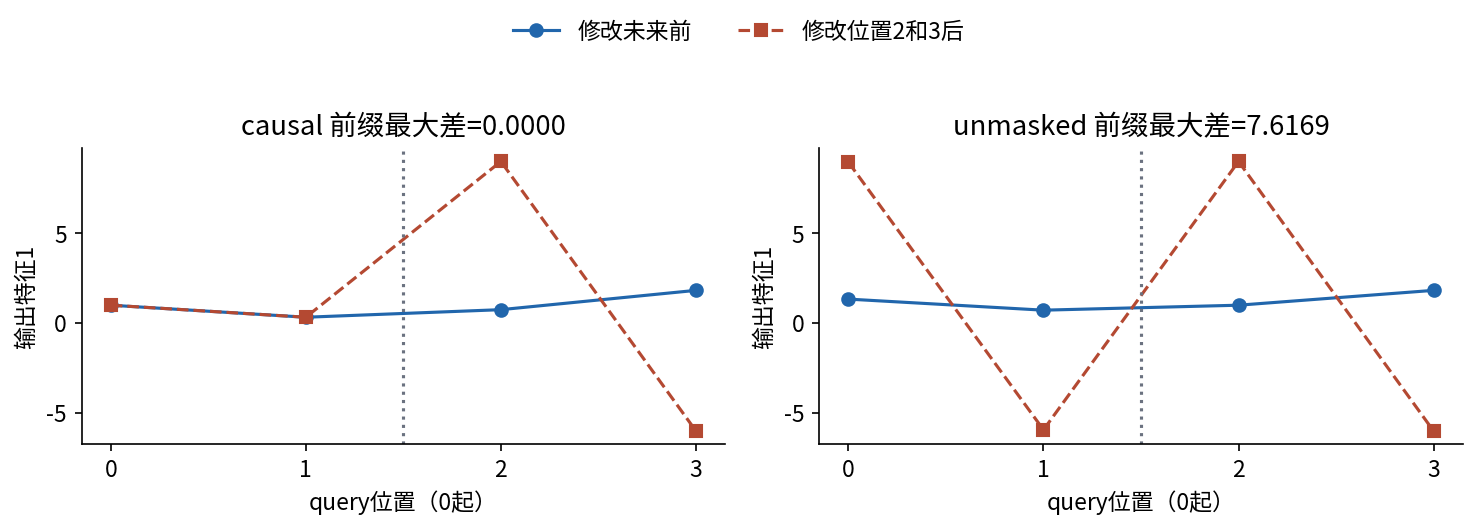

In [7]:
leak=leakage_probe();print(json.dumps(leak,ensure_ascii=False,indent=2))
require(leak['causal']['prefix_max_change']==0.,'因果前缀改变')
require(leak['unmasked']['prefix_max_change']>1.,'注入没有暴露预期差异')
show(figs.leakage({'leakage':leak}))

## 7 所有12配置完整重跑
先核对固定原始数据SHA。没有测试选种子，也没有删掉合法模型未超过零基线的结果。运行结果逐字节与原结果比较；耗时另记录，不拿它作性能基准。

5201 0.0 causal train 1.0190673019319467 test 1.024268344735598 zero 1.0128381543651523
5201 0.0 unmasked train 0.797148757778344 test 0.7546361631827986 zero 1.0128381543651523
5201 8.0 causal train 1.0190673019319467 test 1.024268344735598 zero 1.0128381543651523
5201 8.0 unmasked train 3.133742759677894e-07 test 3.3928471374679343e-07 zero 1.0128381543651523
5202 0.0 causal train 0.9357143515312826 test 1.0501646611654205 zero 1.043263835615121
5202 0.0 unmasked train 0.7074182914424402 test 0.7997329226365196 zero 1.043263835615121
5202 8.0 causal train 0.9357143515312826 test 1.0501646611654205 zero 1.043263835615121
5202 8.0 unmasked train 2.8754903213881116e-07 test 3.388485040442834e-07 zero 1.043263835615121
5203 0.0 causal train 0.9454776247816117 test 1.0051113227660362 zero 0.9956122250742473
5203 0.0 unmasked train 0.7442678457687778 test 0.7559388811597412 zero 0.9956122250742473
5203 8.0 causal train 0.9454776247816117 test 1.0051113227660362 zero 0.9956122250742473
5203

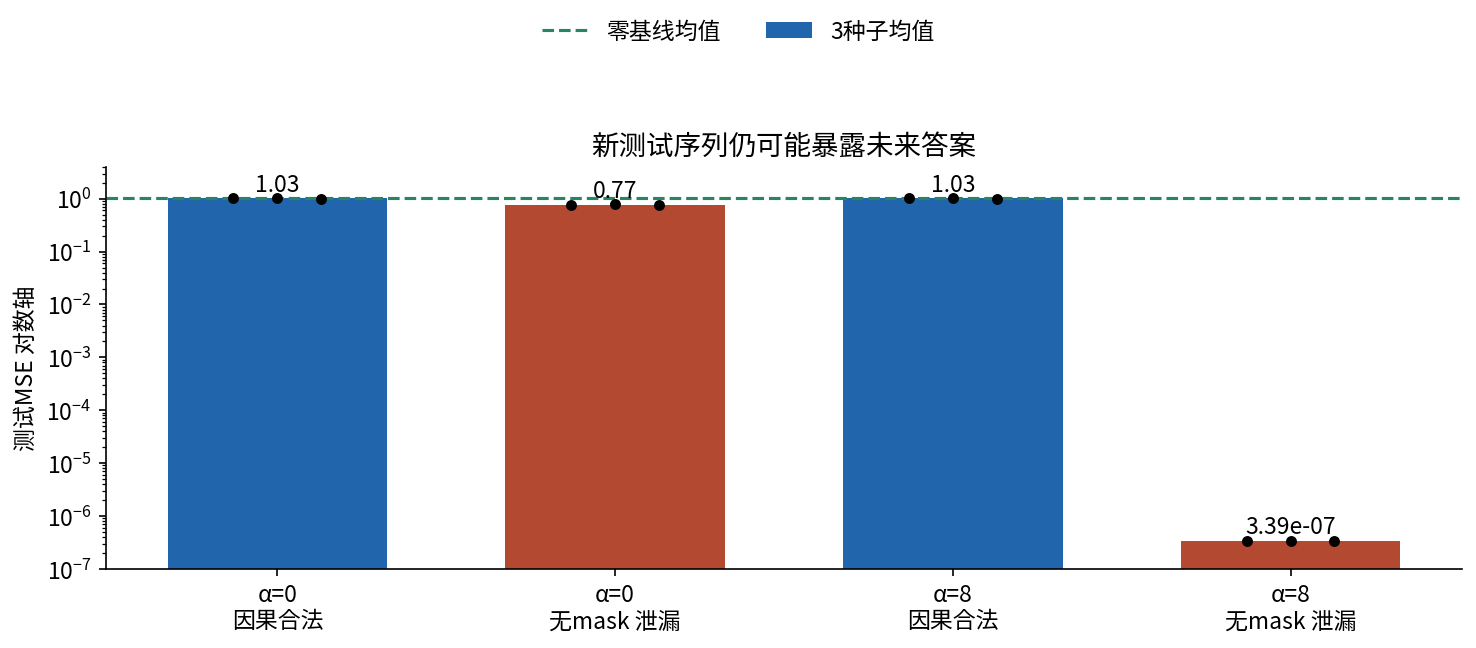

In [8]:
manifest=json.loads((root/'data/manifest.json').read_text())
require(hashlib.sha256((root/'data/sequences.json').read_bytes()).hexdigest()==manifest['sha256'],'数据SHA不一致')
with tempfile.TemporaryDirectory(prefix='dl052-replay-') as folder:
    fresh=run(Path(folder))
    require((Path(folder)/'results.json').read_bytes()==(root/'outputs/results.json').read_bytes(),'结果非原字节复现，先核对版本')
require(len(fresh['runs'])==12,'配置缺失')
for trial in fresh['runs']:print(trial['seed'],trial['alpha'],trial['condition'],'train',trial['train_mse'],'test',trial['test_mse'],'zero',trial['zero_baseline_test_mse'])
show(figs.experiment(fresh))

## 8 不调用训练评价函数独立复算全部测试预测
对每条序列逐query点积，再用已保存系数和截距，逐项平方误差。按序列保存误差，不能用聚合数字代替原始证据。

12×512×3个测试预测独立复算通过；合法因果模型均未胜过零基线


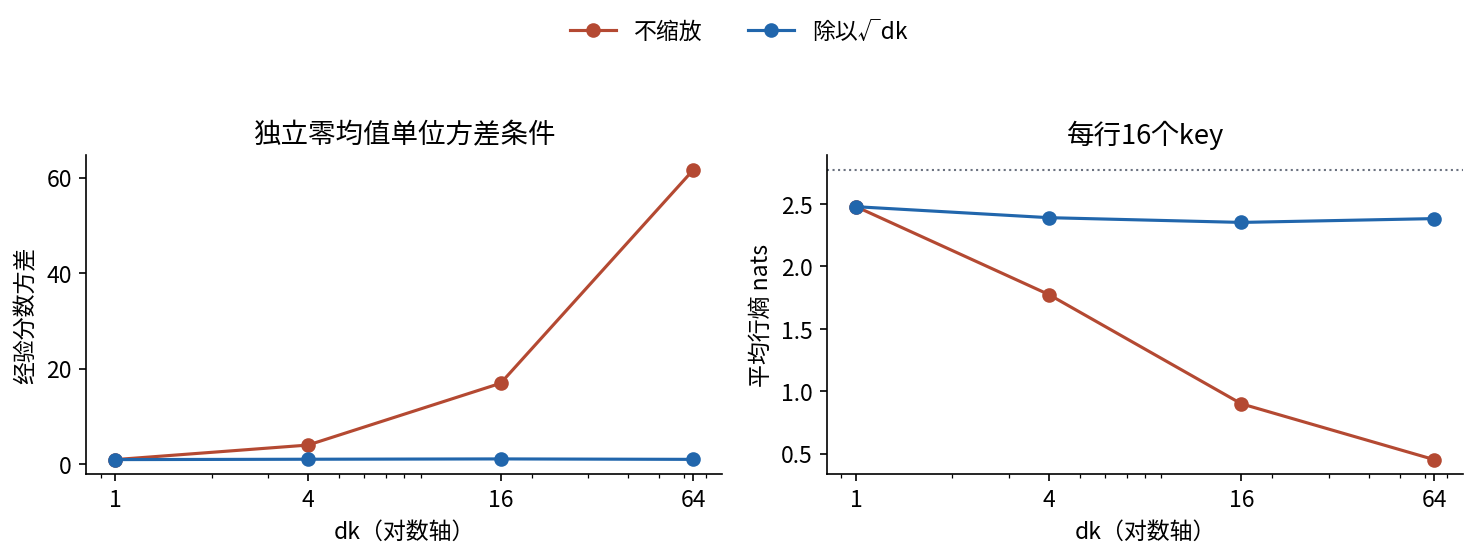

In [9]:
data=json.loads((root/'data/sequences.json').read_text())
for trial in fresh['runs']:
    test=np.array(data['values'][str(trial['seed'])]['test'],dtype=np.float64)
    a=np.array(trial['attention'],dtype=np.float64);coef=trial['coefficient'];pred=[]
    for sequence in test:
        pred.append([coef[0]*sum(float(sequence[j])*float(a[t,j]) for j in range(4))+coef[1] for t in range(3)])
    pred=np.array(pred,dtype=np.float64);per=((pred-test[:,1:])**2).mean(1)
    np.testing.assert_allclose(pred,trial['test_predictions'],atol=2e-14,rtol=1e-13)
    np.testing.assert_allclose(per,trial['test_per_sequence_mse'],atol=2e-14,rtol=1e-13)
    np.testing.assert_allclose(per.mean(),trial['test_mse'],atol=2e-14,rtol=1e-13)
print('12×512×3个测试预测独立复算通过；合法因果模型均未胜过零基线')
show(figs.scaling(fresh))

## 9 不同权重同一输出
代数非唯一性不等同于某个固定模型可以自由换权重，更不能直接声称权重为因果解释。

weights [0.4 0.2 0.4] output 1.0
weights [0.2 0.6 0.2] output 1.0


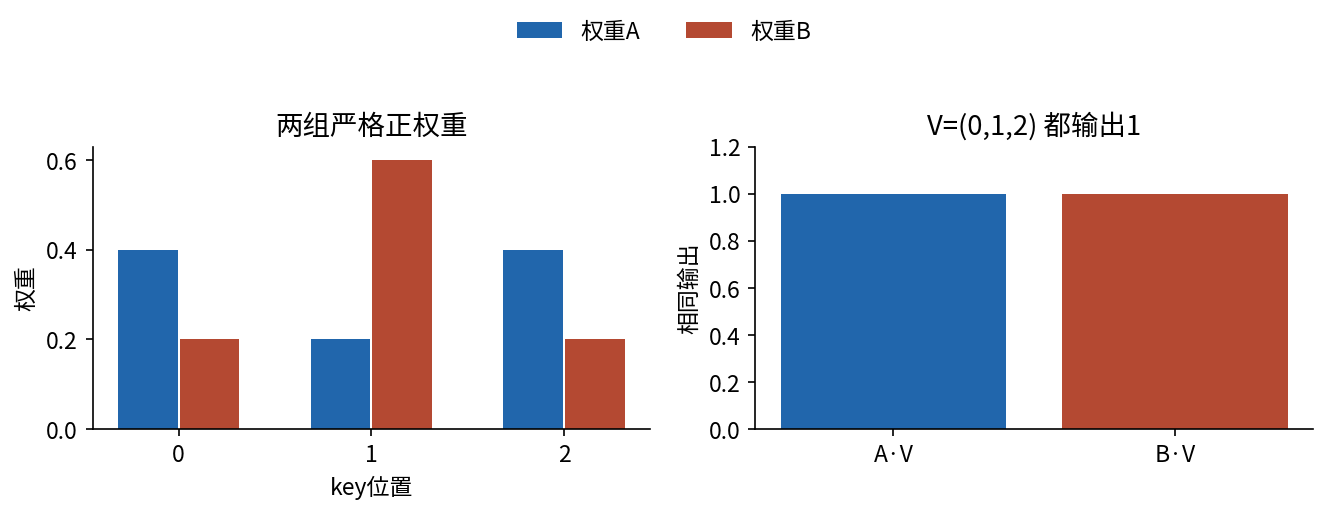

In [10]:
v=np.array([0.,1.,2.],dtype=np.float64)
for a in [np.array([.4,.2,.4],dtype=np.float64),np.array([.2,.6,.2],dtype=np.float64)]:
    s=np.log(a);p=np.exp(s)/np.exp(s).sum();np.testing.assert_allclose(p,a,atol=1e-15);print('weights',a,'output',float(a@v))
show(figs.nonunique({}))

## 10 完整契约测试
这些断言不会在python -O下被移除。当前版本特定的空行行为如果变更，应研究原因，不静默清洗或放宽阈值。

In [11]:
suite=unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result=unittest.TextTestRunner(verbosity=2,stream=sys.stdout).run(suite)
require(result.wasSuccessful(),'契约测试失败')
print('完成全部数值、信息边界与原始结果复算。浏览器/socket/GPU/半精度未测试。')

test_causal_future_injection (test_experiment.AttentionTests.test_causal_future_injection) ... 

ok


test_empirical_empty_library_behavior (test_experiment.AttentionTests.test_empirical_empty_library_behavior) ... 

ok


test_empty_support_rejected (test_experiment.AttentionTests.test_empty_support_rejected) ... 

...

ok


test_two_synchronous_updates (test_experiment.AttentionTests.test_two_synchronous_updates) ... 

ok


----------------------------------------------------------------------
Ran 15 tests in 0.054s

OK


完成全部数值、信息边界与原始结果复算。浏览器/socket/GPU/半精度未测试。
